# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks V: Inception

<br/>
Jiří Fejlek

2026-02-26
<br/>

The next step in our exploration of various convolutional network architectures brings us to the GoogleLeNet (Inception) [[1](#1)]. Up to this point, every convolutional network followed a straightforward design: it consisted of a single sequence of convolution and pooling layers from the input to the output. *Inception* blocks changed that paradigm and introduced parallel branches of convolutional layers. This means that the features obtained by GoogleLeNet from the input image are no longer extracted using the same convolutions with identical kernel sizes, i.e., the extracted features can vary at different levels of "smudging". 

GoogleLeNet, as the name suggests, was developed by Google in 2014, and it won the ImageNet Large-Scale Visual Recognition Challenge that year. GoogleLeNet was continually improved, and its later iterations are known as Inception-V2 through Inception-V4 (GoogLeNet is also known as Inception-V1).


## Table of Contents

- [GoogLeNet](#googlenet)
    - [Inception Block](#inception-block)
    - [Architecture](#inception-architecture)
    - [Training GoogLenet on Fashion-MNIST](#inception-fashion_mnist)
        - [Image Augmentation](#img_aug)
        - [Batch Normalization](#batch_norm)
        - [Label Smoothing](#label_smooth)
        - [Adam](#adam)
- [Inception-V2](#inceptionv2)
- [Inception-V3](#inceptionv3)
- [Inception-V4](#inceptionv4)
    - [Inception-V4 on Fashion-MNIST](#inceptionv4-fmnist)
    - [Simplified Inception-V4 for Fashion-MNIST](#inceptionv4-fmnist)
    - [Inception-V4 on CIFAR-10](#inceptionv4-cifar)
- [References](#references)


## GoogLeNet <a class="anchor" id="googlenet"></a>

Let us start with the original incarnation of the Inception convolutional network. First, we define our usual functions used for training the neural networks

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)  

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

### Inception Block <a class="anchor" id="inception-block"></a>

As we mentioned in the introduction, the inception block is a multi-branch block comprising various convolutional (and one pooling) layers. The goal is to extract features from the input at various levels of detail. These features are subsequently concatenated into a single tensor that serves as the block's output [[1](#1)]. 

One design element to note is that the Inception block employs 1x1 convolutions to control the number of channels, as we saw in the last project on Network in Network (NiN).

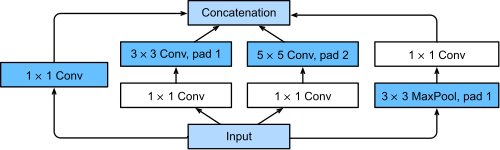

In [6]:
class Inception(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.ReLU())
        
         # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.ReLU())

         # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=5, padding=2), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1), nn.ReLU())
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

### Architecture <a class="anchor" id="inception-architecture"></a>

Let us implement the original GoogLeNet, aka Inception-V1. We should note that, compared to the neural networks that came before, GoogLeNet is very deep (22 layers), and thus vanishing gradients (gradients of earlier layers become extremely small, causing the corresponding weights to stagnate during learning) were a major concern. Hence, GoogLeNet architecture includes auxiliary shallow classifiers inserted into the network during training. The training loss of GoogLeNet is then a sum of the training loss of the whole network and the loss of these 
auxiliary classifiers. Since earlier layers influence auxiliary classifiers' outputs more directly, vanishing gradients should not be as severe. Auxiliary classifiers also aid the regularization [[1](#1)].

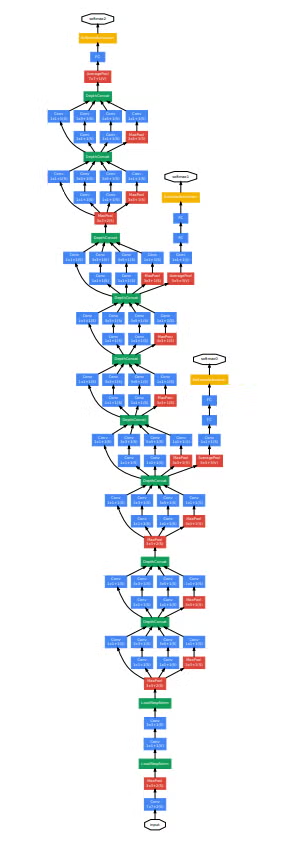

Here, we will use the simplified design without these auxiliary outputs [[2](#2)]. We should note here that we will not encounter auxiliary classifiers in the later designs of neural networks we will discuss in future projects, since there will be alternative remedies for vanishing-gradient problems in very deep neural networks. The first one is batch normalization that we have already employed (chronologically speaking, too early). The second major design element is skip connections in the neural network architecture that we will discuss in the next project, which concerns a residual network: ResNet.

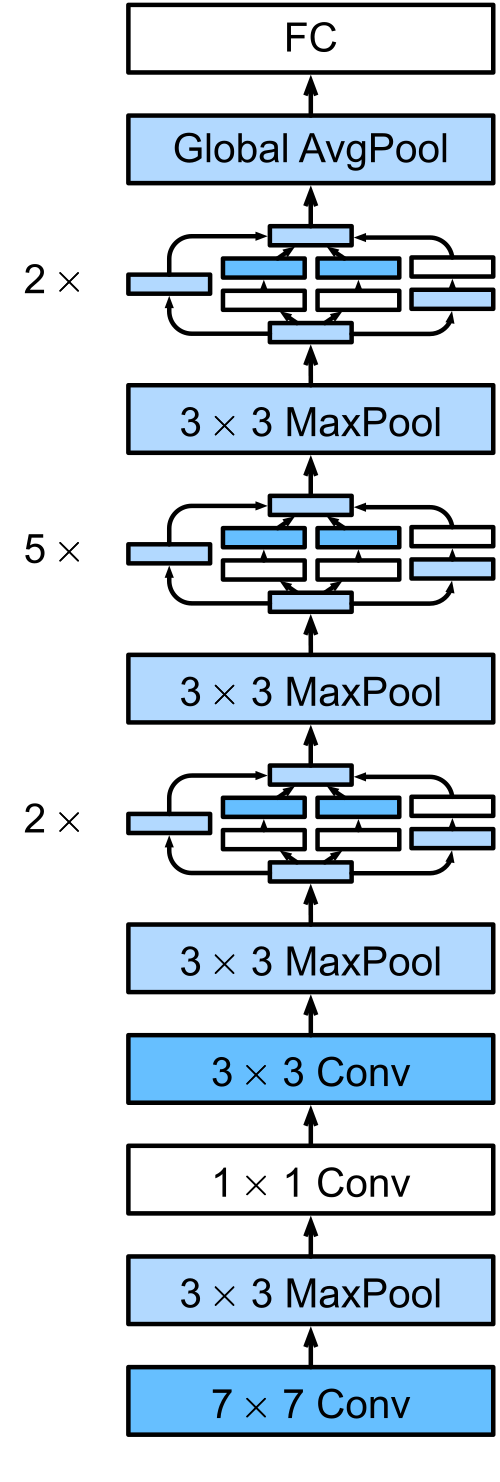!

The architecture of GoogLeNet is summarized in the following table [[1](#1)].

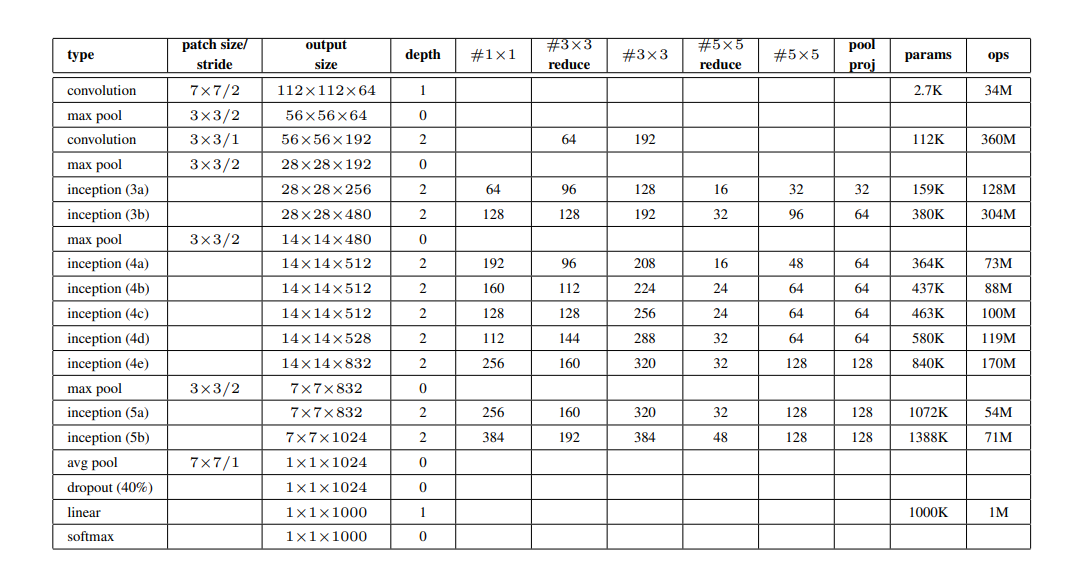

We can also notice that, unlike VGGNet, the classification part uses average pooling and merely one fully connected layer, which significantly reduces the parameter count. 

In [7]:
class GoogLeNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 2
        self.b2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 3
        self.b3 = nn.Sequential(
            Inception(64, (96, 128), (16, 32), 32),
            Inception(128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 4
        self.b4 = nn.Sequential(
            Inception(192, (96, 208), (16, 48), 64),
            Inception(160, (112, 224), (24, 64), 64),
            Inception(128, (128, 256), (24, 64), 64),
            Inception(112, (144, 288), (32, 64), 64),
            Inception(256, (160, 320), (32, 128), 128),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 5
        self.b5 = nn.Sequential(
            Inception(256, (160, 320), (32, 128), 128),
            Inception(384, (192, 384), (48, 128), 128),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten() 
         )

        # stack
        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3, self.b4, self.b5, 
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [8]:
layer_summary(GoogLeNet(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 192, 8, 8])
Sequential output shape:	 torch.Size([1, 480, 4, 4])
Sequential output shape:	 torch.Size([1, 832, 2, 2])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


### Training GoogLenet on Fashion-MNIST <a class="anchor" id="inception-fashion_mnist"></a>

As usual, we will first train GoogLeNet on the Fashion-MNIST dataset [[3](#3)]. We will rescale the images to 64x64 to make the inputs more suitable for GoogLeNet (GoogLeNet is primarily designed for 224x224 ImageNet figures).

In [9]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

# googlenet initialization
GoogleNet_cuda = GoogLeNet(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
GoogleNet_cuda(x);
GoogleNet_cuda.apply(init_weights_he);

The number of parameters of GoogLenet is as follows.

In [10]:
sum(p.numel() for p in GoogleNet_cuda.parameters() if p.requires_grad)

5977530

Despite GoogLeNet being the most complex architecture we have encountered so far, the parameter count of 6 million is quite modest (remember that VGGNet-11 has almost 130 million parameters). This clearly shows how inefficient the simple earlier designs, such as AlexNet and VGGNet, truly were. 

Let us train GoogLeNet.

In [11]:
optim_SGD_cuda =  torch.optim.SGD(GoogleNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 35], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, GoogleNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1057.7347059249878


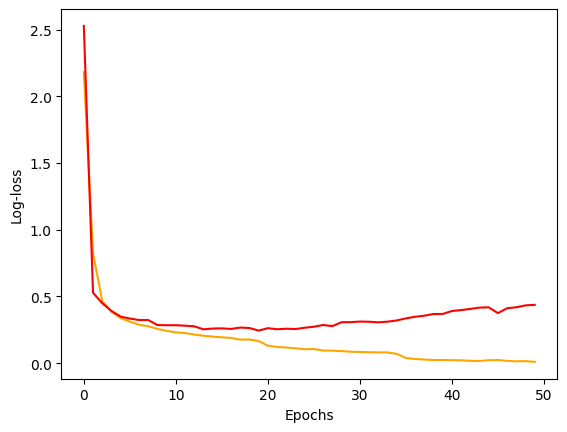

In [12]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

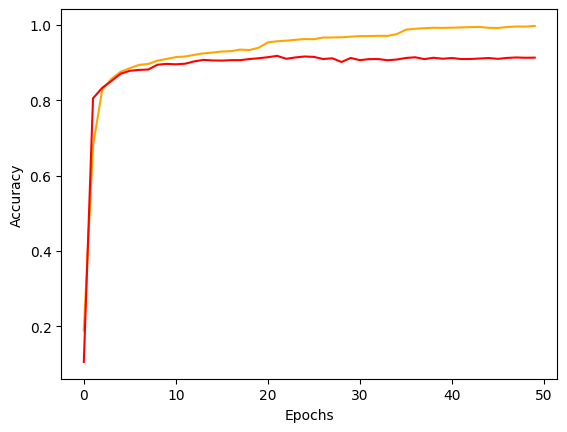

In [13]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

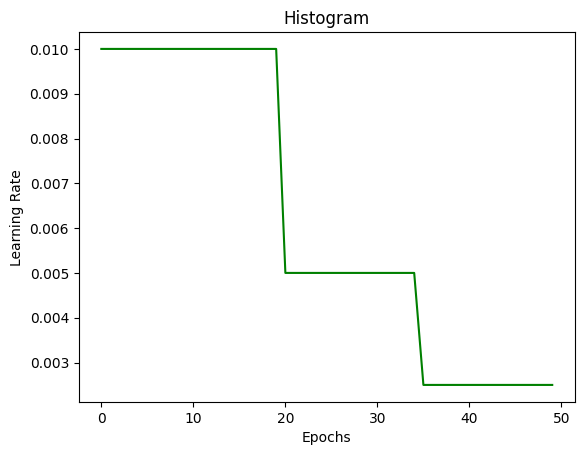

In [14]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [15]:
accu_epochs_train[49]

0.9977999925613403

In [16]:
accu_epochs_test[49]

0.9134999513626099

This accuracy is slightly worse (about 1%) than that obtained from the out-of-the-box VGGNet-11. Next, we employ some tricks, old and new, to improve the performance a bit.

#### Image Augmentation <a class="anchor" id="img_aug"></a>

We start with the standard image augmentation.

In [17]:
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

# googlenet initialization
GoogleNet_cuda = GoogLeNet(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
GoogleNet_cuda(x);
GoogleNet_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(GoogleNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 35], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, GoogleNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1664.2264964580536


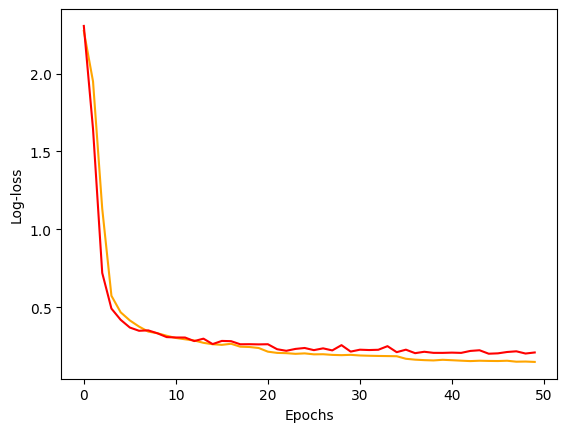

In [18]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

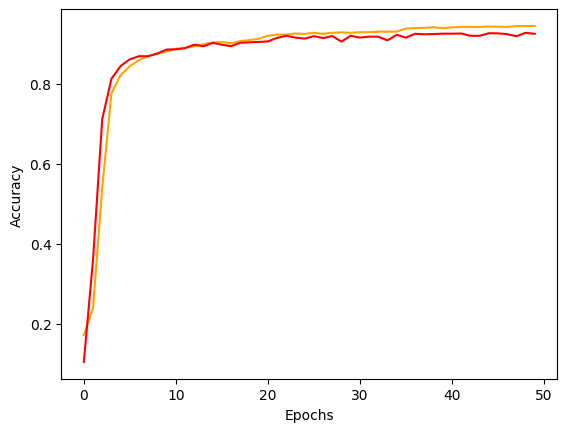

In [19]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

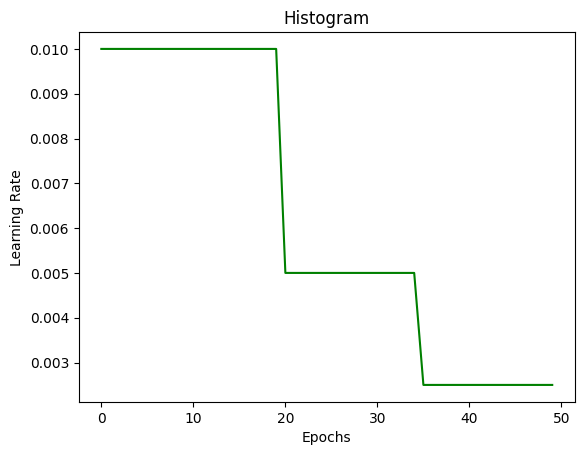

In [20]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [21]:
accu_epochs_train[49]

0.9450666904449463

In [22]:
accu_epochs_test[49]

0.9253000020980835

We improved the accuracy quite a bit, by more than one 1%.

#### Batch Normalization <a class="anchor" id="batch_norm"></a>

We will continue with batch normalization. Batch normalization was actually originally proposed by the designers of GoogLeNet and used in its second version, Inception-V2 [[4](#4)]. 

In [23]:
class Inception_bn(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=5, padding=2), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

In [24]:
class GoogLeNet_bn(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 2
        self.b2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 3
        self.b3 = nn.Sequential(
            Inception_bn(64, (96, 128), (16, 32), 32),
            Inception_bn(128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 4
        self.b4 = nn.Sequential(
            Inception_bn(192, (96, 208), (16, 48), 64),
            Inception_bn(160, (112, 224), (24, 64), 64),
            Inception_bn(128, (128, 256), (24, 64), 64),
            Inception_bn(112, (144, 288), (32, 64), 64),
            Inception_bn(256, (160, 320), (32, 128), 128),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 5
        self.b5 = nn.Sequential(
            Inception_bn(256, (160, 320), (32, 128), 128),
            Inception_bn(384, (192, 384), (48, 128), 128),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten() 
         )

        # stack
        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3, self.b4, self.b5, 
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [25]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

# googlenet initialization
GoogleNet_bn_cuda = GoogLeNet_bn(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
GoogleNet_bn_cuda(x);
GoogleNet_bn_cuda.apply(init_weights_he);

In [26]:
optim_SGD_cuda =  torch.optim.SGD(GoogleNet_bn_cuda.parameters(), lr = 0.02, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, GoogleNet_bn_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1766.9029605388641


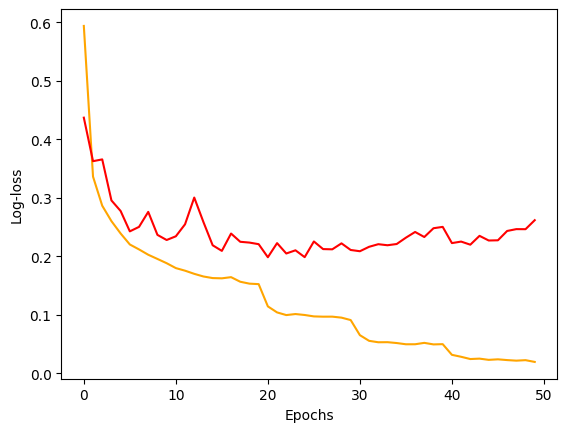

In [27]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

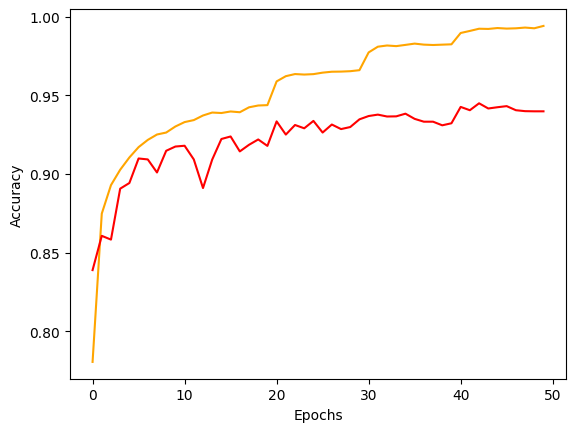

In [28]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

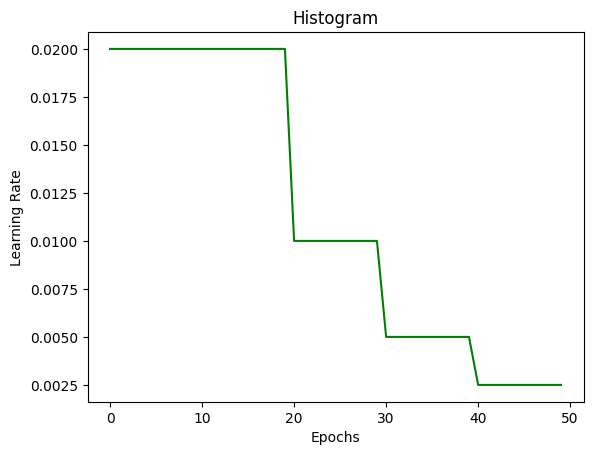

In [29]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [30]:
accu_epochs_train[49]

0.9942166805267334

In [31]:
accu_epochs_test[49]

0.9398999810218811

#### Label Smoothing <a class="anchor" id="label_smooth"></a>

Label smoothing is a regularization technique (new to our projects) proposed in the paper that introduced Inception-V3 [[5](#5)]. When training the classifiers, we use the loss based on multinomial log-likelihood, which can also be interpreted as minimizing Kullback-Leibler divergence $\mathrm{KL} (Q||P) = \sum_k q_k \mathrm{log} \frac{q_k}{p_k}$  between the predicted probability distribution of $p$ and the observed probabilities $q$ (which is  $q_{k, i} = 1$ for the $i$-th observation provided that it belongs to $k$-th class) $$ L = - \sum_i \sum_k q_{k, i} \text{log }p_{k, i} = \mathrm{KL}(Q||P) + \text{const}(Q)$$


When using label smoothing, we replace the observed distribution $q$ (which is 0-1) with a mixture of $q$ and the uniform distribution. This encourages the model to converge to predicted probabilities that are less confident and hence, more robust to new data.

In [32]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

# googlenet initialization
GoogleNet_bn_cuda = GoogLeNet_bn(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
GoogleNet_bn_cuda(x);
GoogleNet_bn_cuda.apply(init_weights_he);

In [33]:
optim_SGD_cuda =  torch.optim.SGD(GoogleNet_bn_cuda.parameters(), lr = 0.02, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, GoogleNet_bn_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1773.2058646678925


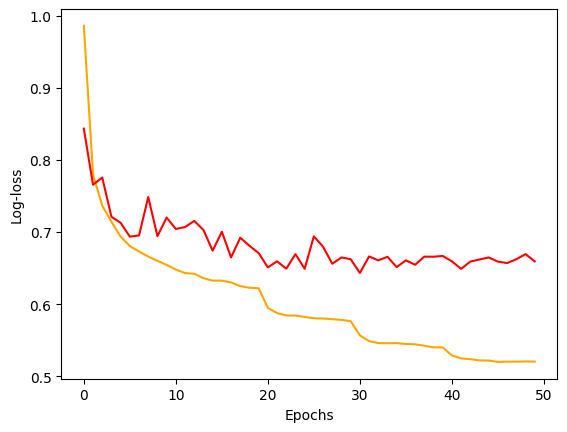

In [34]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

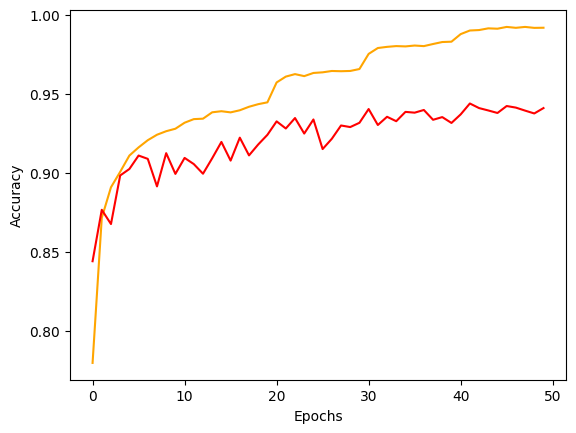

In [35]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

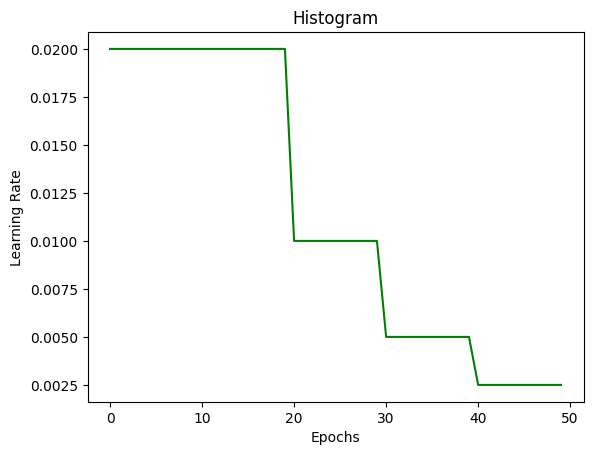

In [36]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [37]:
accu_epochs_train[49]

0.9917833209037781

In [38]:
accu_epochs_test[49]

0.9409999847412109

Here, we achieved the best performance across all of our models, actually. Although the improvement is only minor (0.3%). 

#### Adam <a class="anchor" id="adam"></a>

The last modification we will have a look at concerns the optimization algorithm we will use. Up to this point, we employed the mini-batch stochastic gradient descent (SGD) with momentum. The issue with gradient descent, in general, is that it uses the same step size (aka learning rate) for each dimension of the optimized variable. On the other hand, the second-order methods scale the gradient by the inverse of the Hessian matrix (or by an approximation to it), and hence, adapt the step size for each dimension. Thus, the second-order methods usually converge much faster.

Of course, a full blown second porder method for training a neural network would be way too unwieldy. Still, we can use efficient optimization algorithms that include adaptive scaling for each parameter in some form. Here, we consider Adam [[6](#6)], which is nowadays probably the most popular optimization algorithm for training neural networks. Unlike stochastic gradient descent with momentum, Adan keeps track of not just the momentum of the gradient $g$ (by default $\beta_1 = 0.9$)
$$ v_{i+1} = \beta_1 v_{i} +  (1-\beta_1)g_{i+1},$$
it also tracks the second moment of the gradient (by default $\beta_2 = 0.999$)
$$ s_{i+1} = \beta_2 s_{i} +  (1-\beta_2)g^2_{i+1}.$$ Adam then use the second-order moments to rescale the parameter update
$$ \theta_{i+1} \leftarrow \theta_i  - \eta \frac{\hat v_i}{\sqrt{\hat s_i} + \epsilon},$$
where $\eta$ is the learning rate, $\hat v_i = \frac{v_i}{1-\beta_1^i}$, and $\hat s_i = \frac{s_i}{1-\beta_2^i}$ (the momentum and the second order term are renormalized for the update to ensure that there is no strong early bias to small values of $v_i$ and $s_i$ due to the initialization $v_0 = s_0 = 0$).

We should note here that Adam is not always a strict upgrade over SGD. There are consistent reports that while Adam usually converges faster than SGD, the solution found by SGD can sometimes generalize a bit better [[7](#7),[8](#8),[9](#9),[10](#10)]. 

In [39]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# googlenet initialization
GoogleNet_bn_cuda = GoogLeNet_bn(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
GoogleNet_bn_cuda(x);
GoogleNet_bn_cuda.apply(init_weights_he);

In [40]:
optim_SGD_cuda =  torch.optim.Adam(GoogleNet_bn_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0.000)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, GoogleNet_bn_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1784.3818011283875


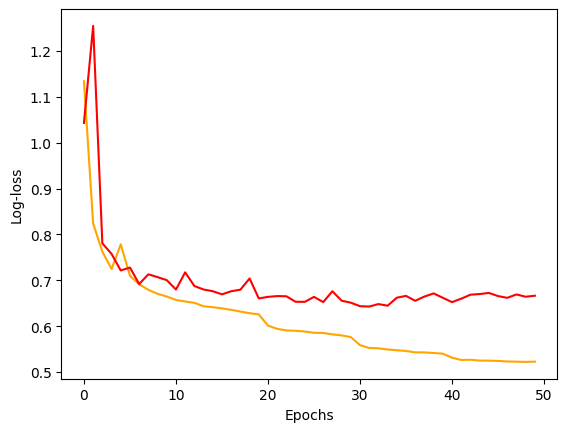

In [41]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

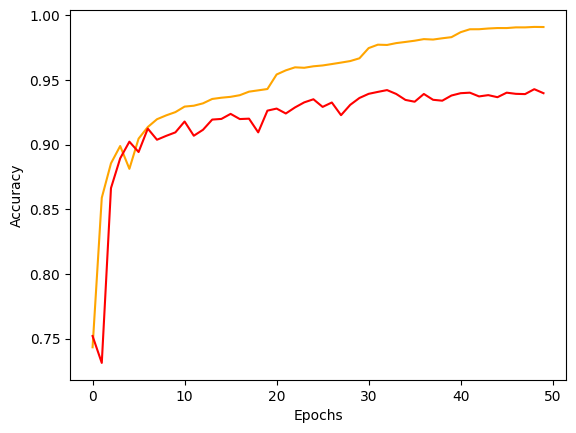

In [42]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

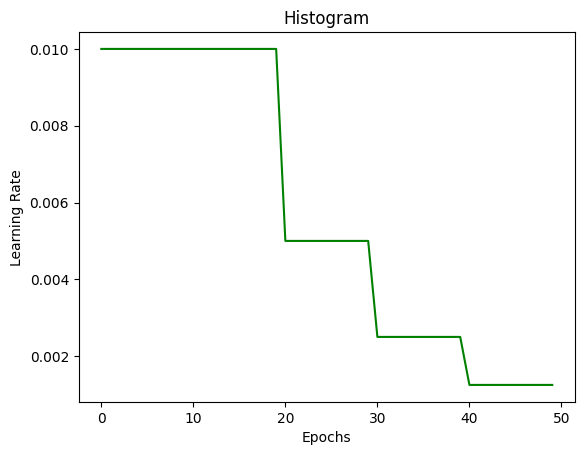

In [43]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [44]:
accu_epochs_train[49]

0.9909666776657104

In [45]:
accu_epochs_test[49]

0.939799964427948

In our case, we have obtained a model with a very similar performance.

## Inception-V2 <a class="anchor" id="inceptionv2"></a>

As we have mentioned, the development of GoogLeNet continued, and new updated versions of the Inception convolutional neural network emerged. Inception-V2 [[4](#4)] introduced batch normalization, which has been widely used in convolutional networks ever since. It also used a mix of average and max pooling in the inception blocks, along with a modified inception block for downsampling (GoogLenet used simple max-pooling layers between inception blocks). 

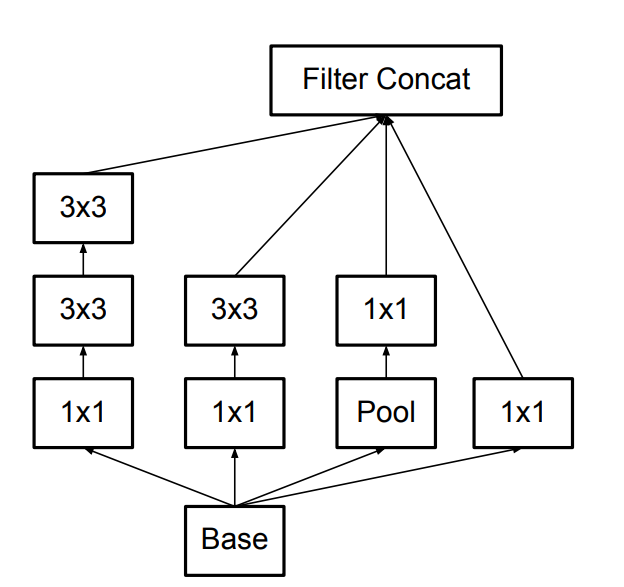

In [46]:
class Inception2_avg(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

In [47]:
class Inception2_max(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

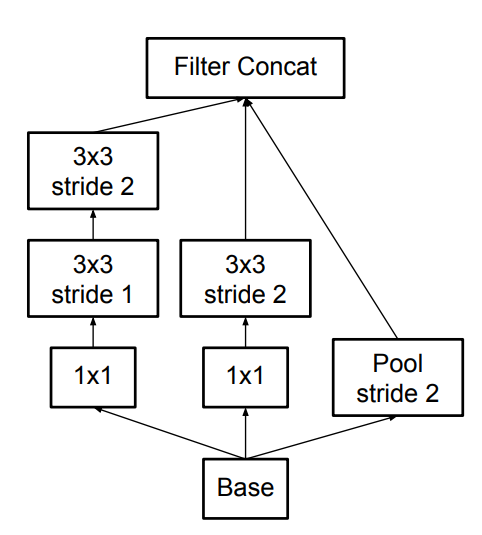

In [48]:
class Inception2_max_pass(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2):
        super().__init__()

      
        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c1[1], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        return torch.cat((branch1, branch2, branch3), dim=1)

The Inception-V2 architecture is in the following table [[4](#4)]. We should note that there is a mistake in the number of channels for channels in the fourth inception block (the numbers do not add up to 576). We modified the number of channels in our implementation to make the total number of channels correct.

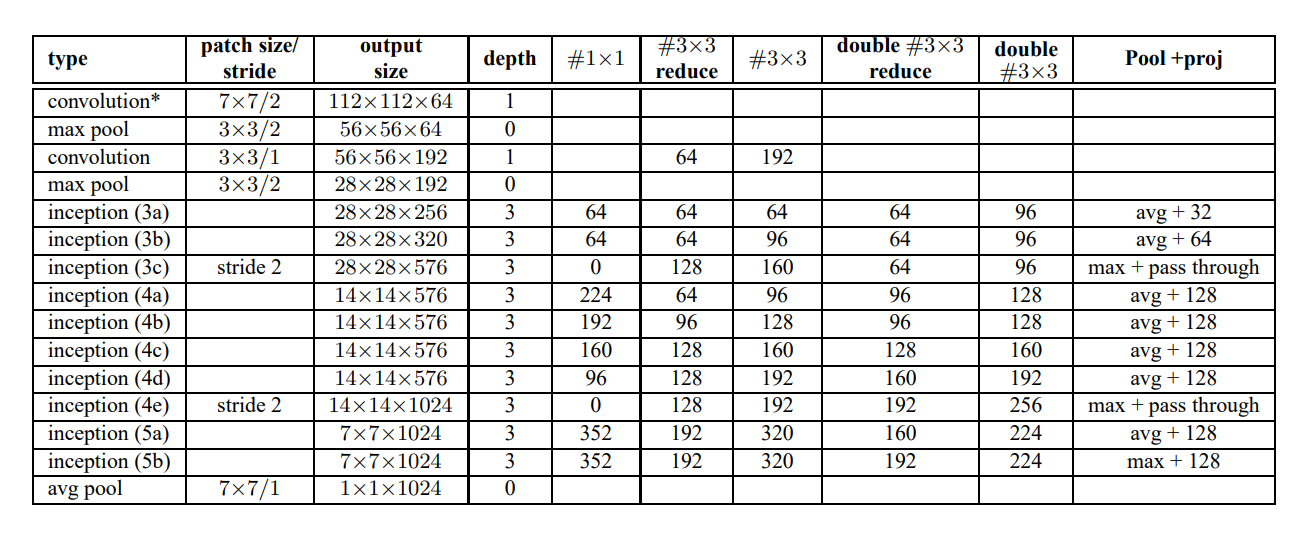

In [49]:
class InceptionV2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 2
        self.b2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 3
        self.b3 = nn.Sequential(
            Inception2_avg(64, (64, 64), (64, 96), 32),
            Inception2_avg(64, (64, 96), (64, 96), 64),
            Inception2_max_pass((128, 160), (64, 96))
        )

        # block 4
        self.b4 = nn.Sequential(
            Inception2_avg(224, (64, 96), (96, 128), 128),
            Inception2_avg(192, (96, 128), (96, 128), 128),
            Inception2_avg(128, (128, 160), (128, 160), 128),
            Inception2_avg(64, (128, 192), (160, 192), 128),
            Inception2_max_pass((128, 192), (192, 256))
        )

        # block 5
        self.b5 = nn.Sequential(
            Inception2_avg(352, (192, 320), (160, 224), 128),
            Inception2_max(352, (192, 320), (192, 224), 128),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten() 
         )

        # stack
        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3, self.b4, self.b5, 
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [50]:
layer_summary(InceptionV2(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 192, 8, 8])
Sequential output shape:	 torch.Size([1, 576, 4, 4])
Sequential output shape:	 torch.Size([1, 1024, 2, 2])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


We first train the model without image augmentation or label smoothing.

In [51]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

# googlenet initialization
InceptionV2_cuda = InceptionV2(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV2_cuda(x);
InceptionV2_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(InceptionV2_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV2_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1260.7485308647156


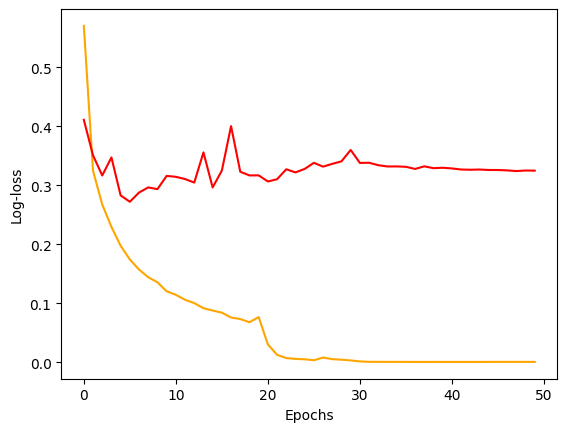

In [52]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

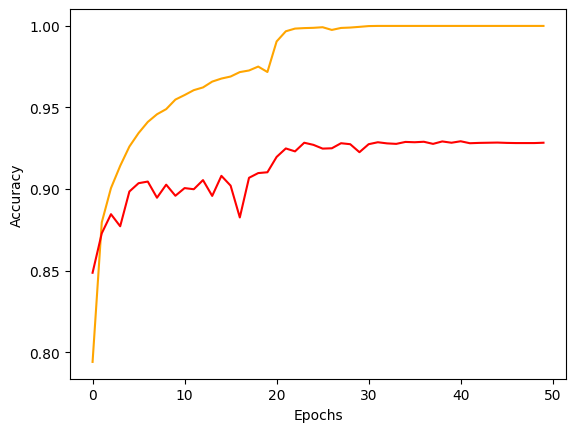

In [53]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

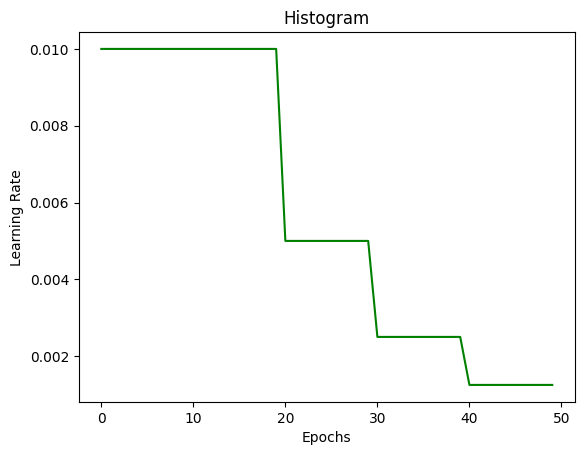

In [54]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [55]:
accu_epochs_train[49]

1.0

In [56]:
accu_epochs_test[49]

0.9283999800682068

Next, we train the model with all improvements as the original GoogLeNet.

In [57]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# googlenet initialization
InceptionV2_cuda = InceptionV2(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV2_cuda(x);
InceptionV2_cuda.apply(init_weights_he);

In [58]:
optim_SGD_cuda =  torch.optim.Adam(InceptionV2_cuda.parameters(), lr = 0.03, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV2_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1869.2133131027222


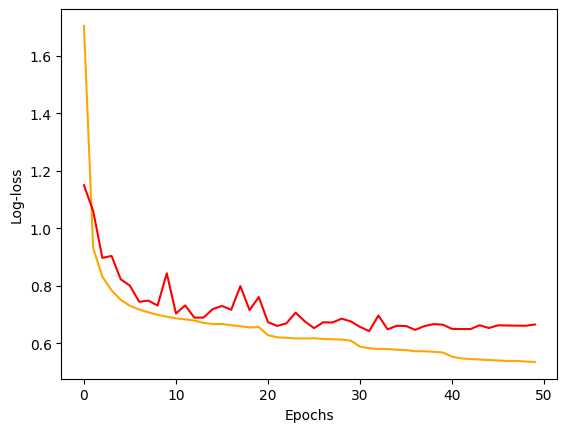

In [59]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

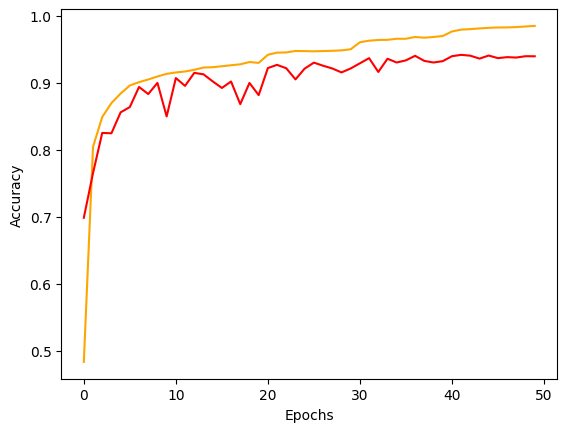

In [60]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

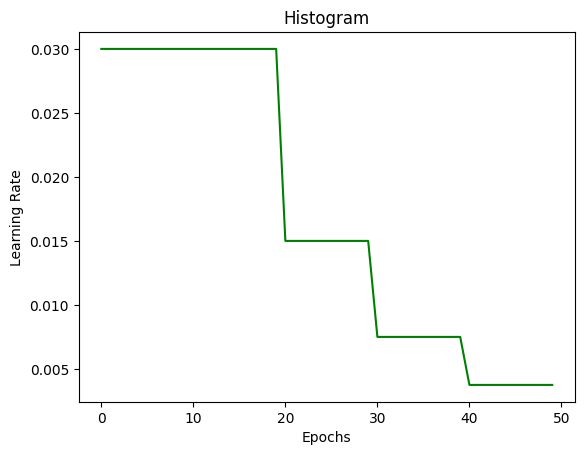

In [61]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [62]:
accu_epochs_train[49]

0.9852166771888733

In [63]:
accu_epochs_test[49]

0.9398999810218811

We achieved a similar performance to GoogLeNet.

## Inception-V3 <a class="anchor" id="inceptionv3"></a>

Inception-V3 is another evolution of the inception architecture [[5](#5)]. It uses new blocks with 1x7, 7x1, 3x1, and 1x3 *factorized* convolutions. The first new block is as follows.

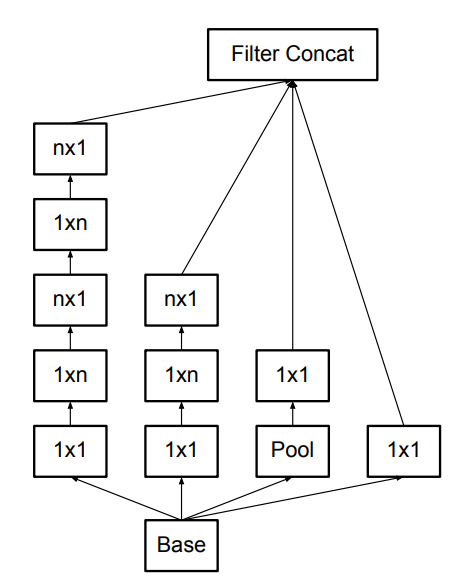

In [64]:
class Inception3_fctr(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(),  nn.ReLU())


        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[0], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[0], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[0], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[0], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1),
                                nn.LazyBatchNorm2d(),
                                nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

This block has an alternative version that downsamples the features with a stride = 2.

In [65]:
class Inception3_fctr_pass(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c1[1], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[0], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[0], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[0], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU()
                               )
        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        return torch.cat((branch1, branch2, branch3), dim=1)

The second new block has the following architecture [[5](#5)]. 

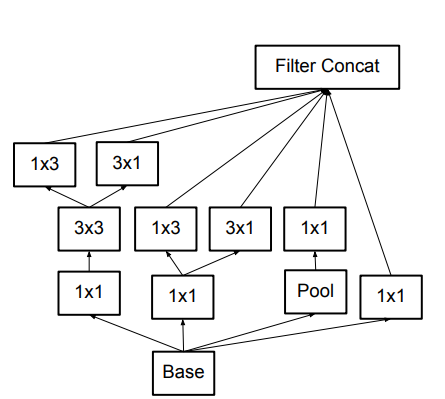

In [66]:
class Inception3_exp(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(),  nn.ReLU())


        # Branch 2
        self.b2_1 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b2_2_1 = nn.Sequential(nn.LazyConv2d(c2[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b2_2_2 = nn.Sequential(nn.LazyConv2d(c2[1], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()) 
 

        # Branch 3
        self.b3_1 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                  nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU()
                                  )
        
        self.b3_2_1 = nn.Sequential(nn.LazyConv2d(c3[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b3_2_2 = nn.Sequential(nn.LazyConv2d(c3[1], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()) 
        

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1),
                                nn.LazyBatchNorm2d(),
                                nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)

        branch2 = self.b2_1(x)
        branch2_1 = self.b2_2_1(x)
        branch2_2 = self.b2_2_2(x)

        branch3 = self.b3_1(x)
        branch3_1 = self.b3_2_1(branch3)
        branch3_2 = self.b3_2_2(branch3)

        branch4 = self.b4(x)
        return torch.cat((branch1, branch2_1, branch2_2, branch3_1, branch3_2, branch4), dim=1)

The last block used in Inception-V3 is the same as in Inception-V2; we already implemented it as *Inception2_avg* and *Inception2_max_pass*.

The full architecture of Inception-V3 is unfortunately not fully described in [[5](#5)], thus we based our number of channels in the inception blocks on the PyTorch implementation (https://docs.pytorch.org/vision/main/models/inception.html).

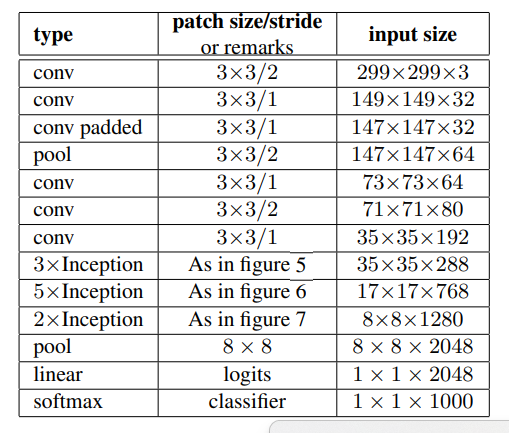

In [67]:
class InceptionV3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(64, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # block 2
        self.b2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(80, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU()
        )

        # block 3
        self.b3 = nn.Sequential(
            Inception2_avg(64, (48, 64), (64, 96), 32),
            Inception2_avg(64, (48, 64), (64, 96), 64),
            Inception2_avg(64, (48, 64), (64, 96), 64),
            Inception2_max_pass((320, 384), (64, 96))
        )

        # block 4
        self.b4 = nn.Sequential(
            Inception3_fctr(192, (128, 192), (128, 192), 192),
            Inception3_fctr(192, (160, 192), (160, 192), 192),
            Inception3_fctr(192, (160, 192), (160, 192), 192),
            Inception3_fctr(192, (192, 192), (192, 192), 192),
            Inception3_fctr_pass((192, 320), (192, 192)),
        )

        # block 5
        self.b5 = nn.Sequential(
            Inception3_exp(320, (384, 384), (448, 384), 192),
            Inception3_exp(320, (384, 384), (448, 384), 192),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten() 
         )

        # stack
        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3, self.b4, self.b5, 
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [68]:
layer_summary(InceptionV3(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 15, 15])
Sequential output shape:	 torch.Size([1, 192, 8, 8])
Sequential output shape:	 torch.Size([1, 768, 4, 4])
Sequential output shape:	 torch.Size([1, 1280, 2, 2])
Sequential output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


Again, no image augmentation and label smoothing first. 

In [69]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

# googlenet initialization
InceptionV3_cuda = InceptionV3(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV3_cuda(x);
InceptionV3_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(InceptionV3_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV3_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1422.9231972694397


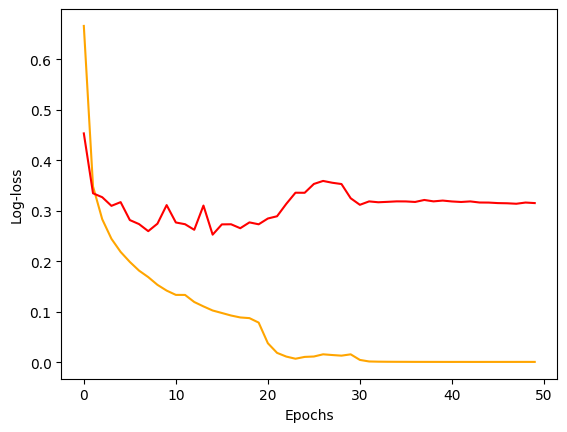

In [70]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

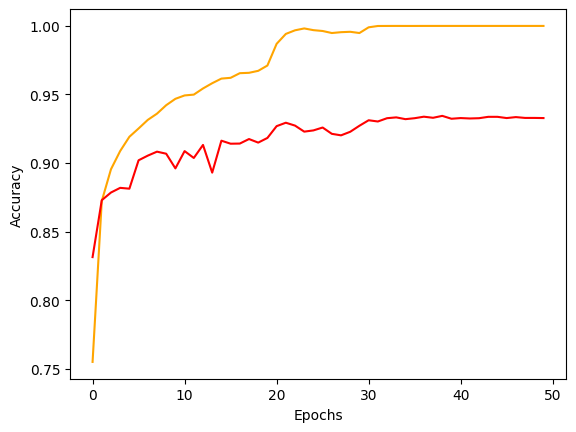

In [71]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

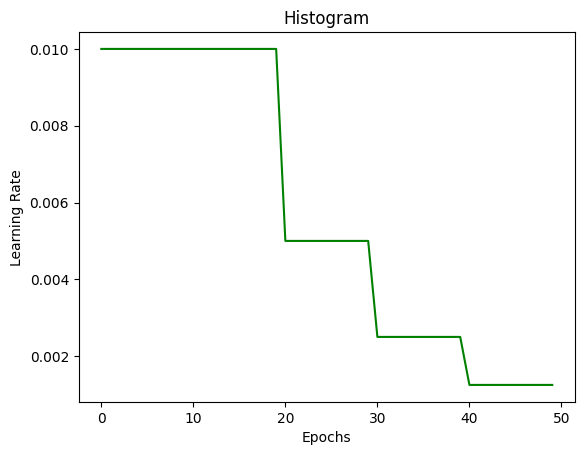

In [72]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [73]:
accu_epochs_train[49]

1.0

In [74]:
accu_epochs_test[49]

0.9327999949455261

The results with image augmentation and label smoothing are as follows.

In [75]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# googlenet initialization
InceptionV3_cuda = InceptionV3(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV3_cuda(x);
InceptionV3_cuda.apply(init_weights_he);

In [76]:
optim_SGD_cuda =  torch.optim.Adam(InceptionV3_cuda.parameters(), lr = 0.02, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV3_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2052.0842883586884


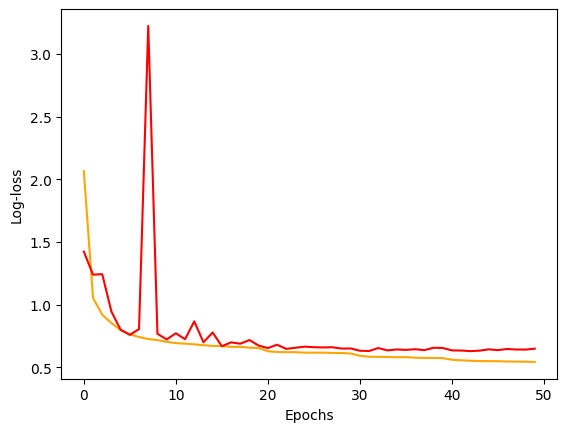

In [77]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

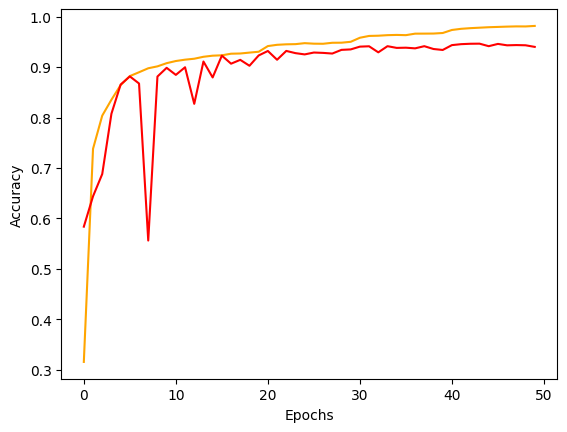

In [78]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

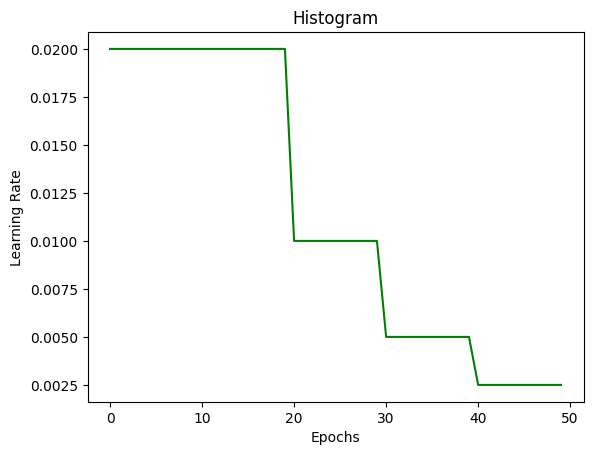

In [79]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [80]:
accu_epochs_train[49]

0.9816666841506958

In [81]:
accu_epochs_test[49]

0.9400999546051025

Again, the performance is mostly the same. 

## Inception-V4 <a class="anchor" id="inceptionv4"></a>

The inception blocks in Inception-V4 [[11](#11)] are very similar to V3; we already implemented block A as *Inception2_avg*, the number of channels are as follows.

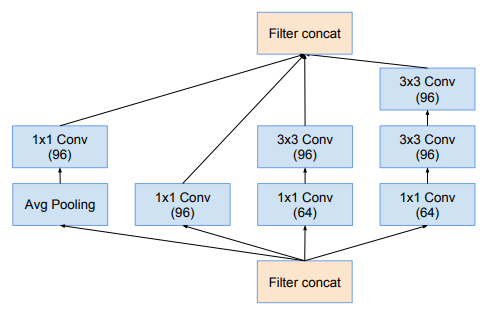

Block B is *Inception3_fctr* in our implementation, but we need more flexible parametrization of the number of channels.

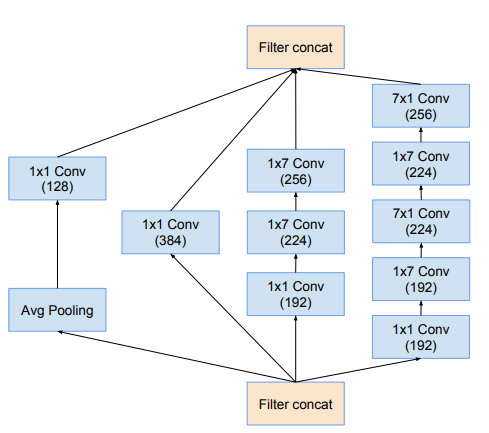

In [82]:
class Inception4_B(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(),  nn.ReLU())


        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[2], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[2], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[3], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[4], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1),
                                nn.LazyBatchNorm2d(),
                                nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

Block C is very similar to *Inception3_exp*, the 3x3 convolution in branch 3 is just factorized into two convolutions 1x3 and 3x1.

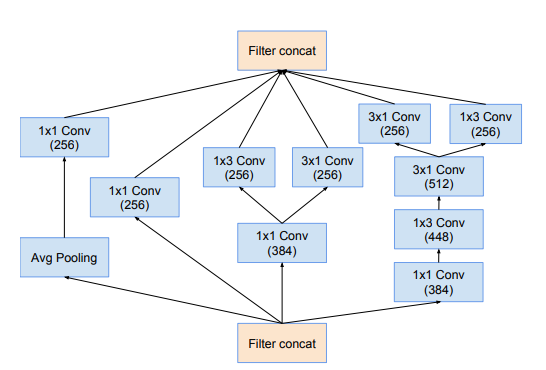

In [83]:
class Inception4_C(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(),  nn.ReLU())


        # Branch 2
        self.b2_1 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b2_2_1 = nn.Sequential(nn.LazyConv2d(c2[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b2_2_2 = nn.Sequential(nn.LazyConv2d(c2[1], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()) 
 

        # Branch 3
        self.b3_1 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                  nn.LazyConv2d(c3[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                  nn.LazyConv2d(c3[2], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                                  )
        
        self.b3_2_1 = nn.Sequential(nn.LazyConv2d(c3[3], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b3_2_2 = nn.Sequential(nn.LazyConv2d(c3[3], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()) 
        

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1),
                                nn.LazyBatchNorm2d(),
                                nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)

        branch2 = self.b2_1(x)
        branch2_1 = self.b2_2_1(x)
        branch2_2 = self.b2_2_2(x)

        branch3 = self.b3_1(x)
        branch3_1 = self.b3_2_1(branch3)
        branch3_2 = self.b3_2_2(branch3)

        branch4 = self.b4(x)
        return torch.cat((branch1, branch2_1, branch2_2, branch3_1, branch3_2, branch4), dim=1)

The first reduction module (for downsampling the images) has parameters $k = 192, l = 224, m = 256, n = 384$ (V in the sketch denotes valid padding, i.e., padding = 0; we will always use padding that does not decrease the size of the image in our implementation, since we are dealing with much smaller images).

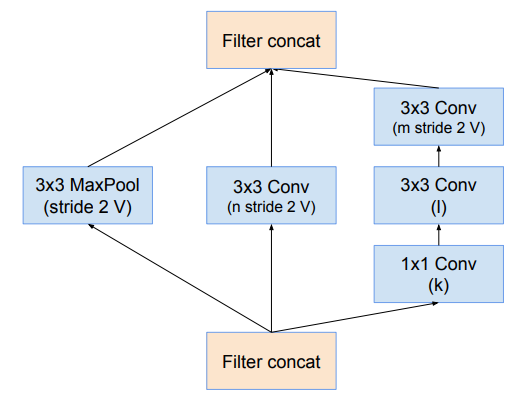

In [84]:
class Inception4_red1(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[2], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)

        
        return torch.cat((branch1, branch2, branch3), dim=1)

The second reduction is structuraly the same as *Inception3_fctr_pass.*

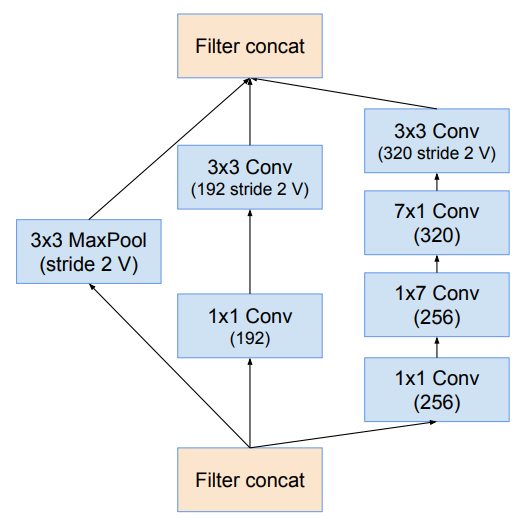

In [85]:
class Inception4_red2(nn.Module):

    def __init__(self, c1, c2):
        super().__init__()


        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c1, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[2], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[3], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        return torch.cat((branch1, branch2, branch3), dim=1)

The biggest difference from V3 is a more complex *stem*.

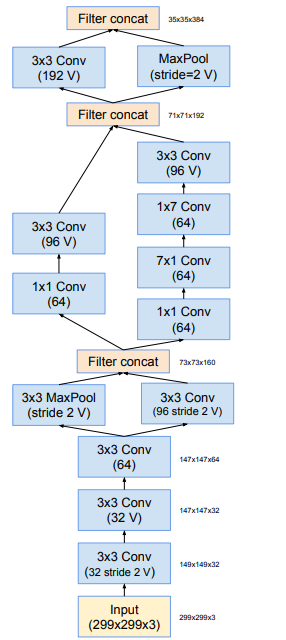 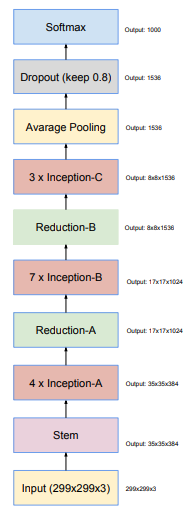

In [86]:
class InceptionV4_stem(nn.Module):
    def __init__(self):
        super().__init__()

        # block 1
        self.sb1 = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),     
        )

        self.sb1_1 = nn.Sequential(nn.LazyConv2d(96, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.sb1_2 =  nn.MaxPool2d(kernel_size=3, stride=2, padding = 1)

        # block 2
        self.sb2_1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1, stride=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(96, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU()
        )

        self.sb2_2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1, stride=1, padding = 0), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=(7,1), stride=1, padding = (3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=(1,7), stride=1, padding = (0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(96, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU()
        )

        # block 3
        self.sb3_1 = nn.Sequential(nn.LazyConv2d(192, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.sb3_2 = nn.MaxPool2d(kernel_size=3, stride=2, padding = 1)

    def forward(self, x):
        sblock1 = self.sb1(x)
        sblock1_1 = self.sb1_1(sblock1)
        sblock1_2 = self.sb1_2(sblock1)
        sblock1_result = torch.cat((sblock1_1, sblock1_2), dim=1)

        sblock2_1 = self.sb2_1(sblock1_result)
        sblock2_2 = self.sb2_2(sblock1_result)
        sblock2_result = torch.cat((sblock2_1, sblock2_2), dim=1)

        sblock3_1 = self.sb3_1(sblock2_result)
        sblock3_2 = self.sb3_2(sblock2_result)

        return torch.cat((sblock3_1, sblock3_2), dim=1)

In [87]:
class InceptionV4(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # stem
        self.stem = InceptionV4_stem()

        # body block 1
        self.bblock1 =  nn.Sequential(
            Inception2_avg(96, (64, 96), (64, 96), 96),
            Inception2_avg(96, (64, 96), (64, 96), 96),
            Inception2_avg(96, (64, 96), (64, 96), 96),
            Inception4_red1(384, (192, 224, 256))
        )

        self.bblock2 =  nn.Sequential(
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_red2(192, (256, 256, 320, 320))
        )

        self.bblock3 =  nn.Sequential(
            Inception4_C(256, (384,256), (384,448,512,256), 256),
            Inception4_C(256, (384,256), (384,448,512,256), 256),
            Inception4_C(256, (384,256), (384,448,512,256), 256),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
        )
        
        self.net_stack = nn.Sequential(
            self.stem, self.bblock1, self.bblock2, self.bblock3,
            nn.Dropout(0.1),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [88]:
layer_summary(InceptionV4(10),(1, 1, 64, 64))

InceptionV4_stem output shape:	 torch.Size([1, 384, 8, 8])
Sequential output shape:	 torch.Size([1, 1024, 4, 4])
Sequential output shape:	 torch.Size([1, 1536, 2, 2])
Sequential output shape:	 torch.Size([1, 1536])
Dropout output shape:	 torch.Size([1, 1536])
Linear output shape:	 torch.Size([1, 10])


### Inception-V4 on Fashion-MNIST <a class="anchor" id="inceptionv4-fmnist"></a>

First, we again train Inception-V4 without label smoothing or image augmentation.

In [89]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

# googlenet initialization
InceptionV4_cuda = InceptionV4(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV4_cuda(x);
InceptionV4_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.SGD(InceptionV4_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV4_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1724.5938045978546


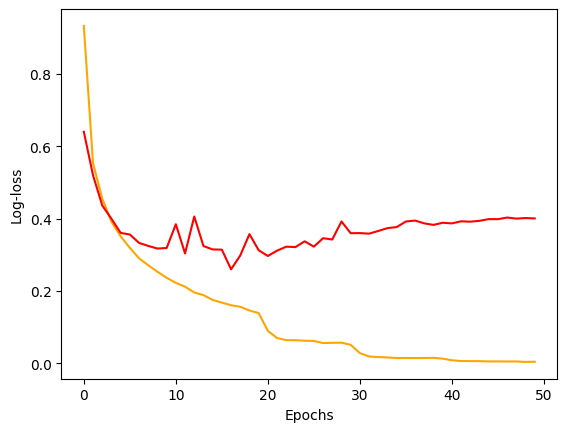

In [90]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

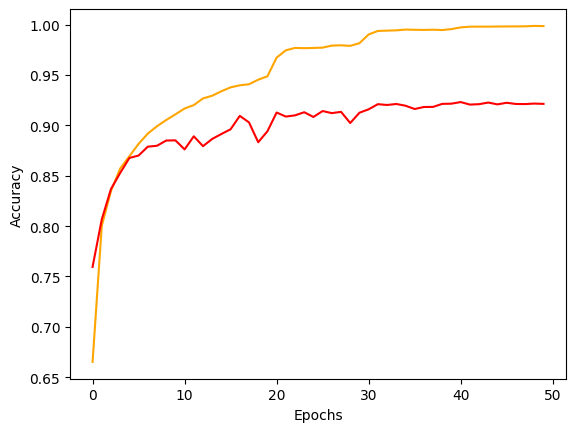

In [91]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

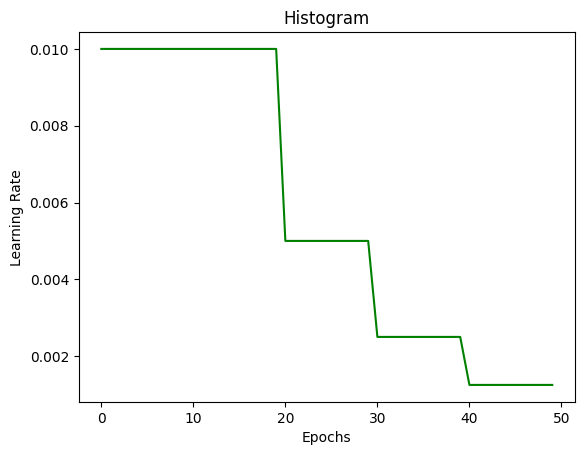

In [92]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [93]:
accu_epochs_train[49]

0.9986333250999451

In [94]:
accu_epochs_test[49]

0.9213999509811401

Then, we add label smoothing and image augmentation back in.

In [95]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# googlenet initialization
InceptionV4_cuda = InceptionV4(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV4_cuda(x);
InceptionV4_cuda.apply(init_weights_he);

In [96]:
optim_SGD_cuda =  torch.optim.Adam(InceptionV4_cuda.parameters(), lr = 0.05, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV4_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2372.075942993164


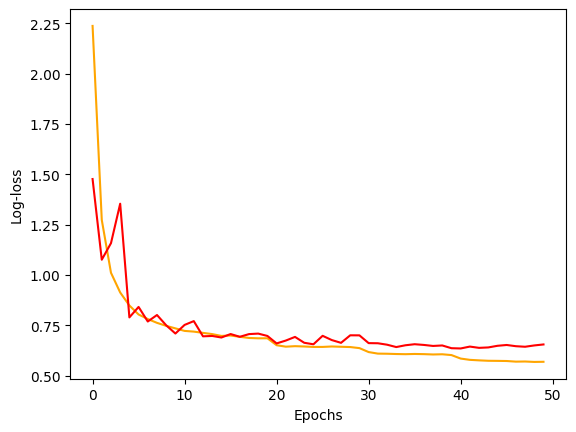

In [97]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

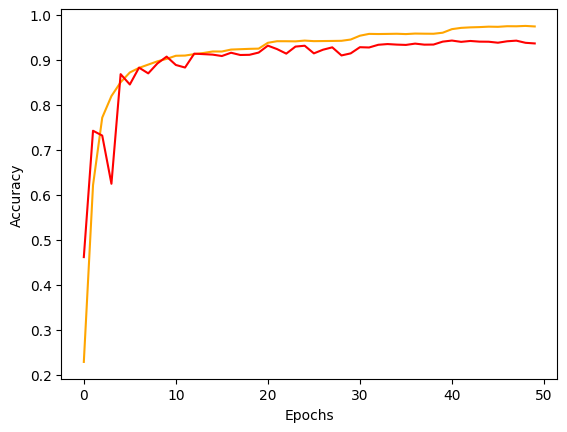

In [98]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

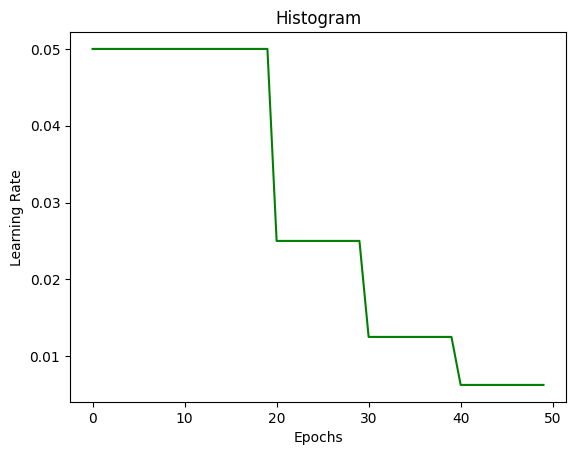

In [99]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [100]:
accu_epochs_train[49]

0.9742666482925415

In [101]:
accu_epochs_test[49]

0.9364999532699585

The Inception-V4 actually seems the worst. This is probably due to being designed for a much larger dataset of much larger images. Let us try to downscale the Inception-V4 a bit.

### Simplified Inception-V4 for Fashion-MNIST <a class="anchor" id="sinceptionv4-fmnist"></a>

We will first reduce the stem a bit.

In [102]:
class Inception_stem_red(nn.Module):
    def __init__(self):
        super().__init__()

        self.sb1 = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),     
        )

        self.sb1_1 = nn.Sequential(nn.LazyConv2d(48, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.sb1_2 =  nn.MaxPool2d(kernel_size=3, stride=2, padding = 1)


    def forward(self, x):
        sblock1 = self.sb1(x)
        sblock1_1 = self.sb1_1(sblock1)
        sblock1_2 = self.sb1_2(sblock1)
        
        return torch.cat((sblock1_1, sblock1_2), dim=1)

We will also reduce the number of channels in the inception blocks.

In [103]:
class Inception_red(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # stem
        self.stem = Inception_stem_red()

        # body block 1
        self.bblock1 =  nn.Sequential(
            Inception2_avg(48, (64, 48), (32, 48), 48),
            Inception2_avg(48, (64, 48), (32, 48), 48),
            Inception4_red1(192, (96, 112, 128))
        )

        self.bblock2 =  nn.Sequential(
            Inception4_B(192, (96, 112, 128), (96, 96, 112, 112, 128), 64),
            Inception4_B(192, (96, 112, 128), (96, 96, 112, 112, 128), 64),
            Inception4_B(192, (96, 112, 128), (96, 96, 112, 112, 128), 64),
            Inception4_B(192, (96, 112, 128), (96, 96, 112, 112, 128), 64),
            Inception4_red2(96, (128, 128, 160, 160))
        )

        self.bblock3 =  nn.Sequential(
            Inception4_C(128, (192,128), (192,224,256,128), 128),
            Inception4_C(128, (192,128), (192,224,256,128), 128),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
        )
        
        self.net_stack = nn.Sequential(
            self.stem, self.bblock1, self.bblock2, self.bblock3,
            nn.Dropout(0.1),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [104]:
layer_summary(Inception_red(10),(1, 1, 32, 32))

Inception_stem_red output shape:	 torch.Size([1, 80, 16, 16])
Sequential output shape:	 torch.Size([1, 512, 8, 8])
Sequential output shape:	 torch.Size([1, 768, 4, 4])
Sequential output shape:	 torch.Size([1, 768])
Dropout output shape:	 torch.Size([1, 768])
Linear output shape:	 torch.Size([1, 10])


In [105]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [32, 32], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([32,32]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# googlenet initialization
Inception_red_cuda = Inception_red(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_red_cuda(x);
Inception_red_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.Adam(Inception_red_cuda.parameters(), lr = 0.05, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.01)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, Inception_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)


1951.5887842178345


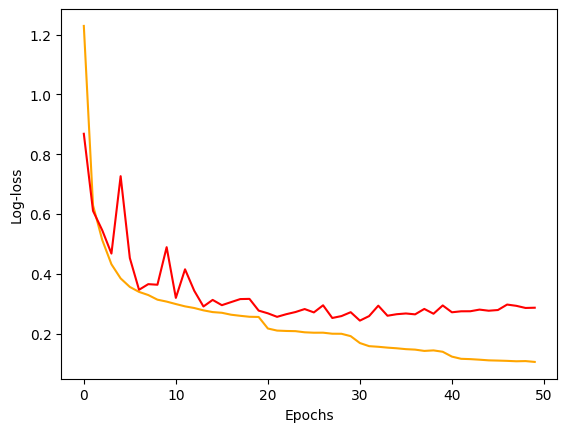

In [106]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

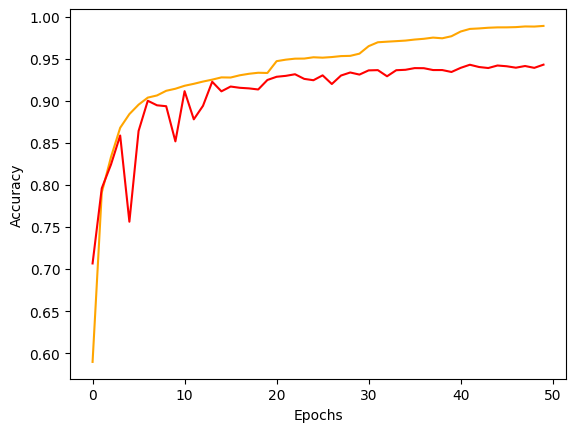

In [107]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

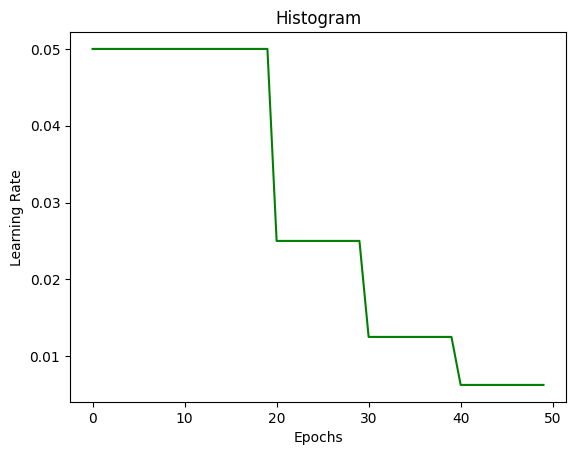

In [108]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [109]:
accu_epochs_train[49]

0.989050030708313

In [110]:
accu_epochs_test[49]

0.9429999589920044

We have quite easily obtained the best performing version of Inception on Fashion-MNIST among the models we have tested in this project.

### Inception-V4 on CIFAR-10 <a class="anchor" id="inceptionv4-cifa"></a>

To conclude this project, we will train the Inception-V4 model on the CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html). We will use the image augmentation and label smoothing right away.

In [111]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[64,64], scale = [0.8,1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.Resize([64,64])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 200, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 200, shuffle = False)


# googlenet initialization
InceptionV4_cuda = InceptionV4(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV4_cuda(x);
InceptionV4_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.Adam(InceptionV4_cuda.parameters(), lr = 0.03, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40, 50, 60, 70, 80], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, InceptionV4_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

4774.090048551559


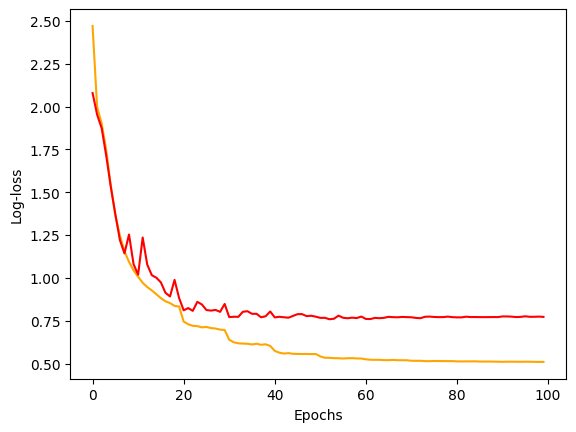

In [112]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

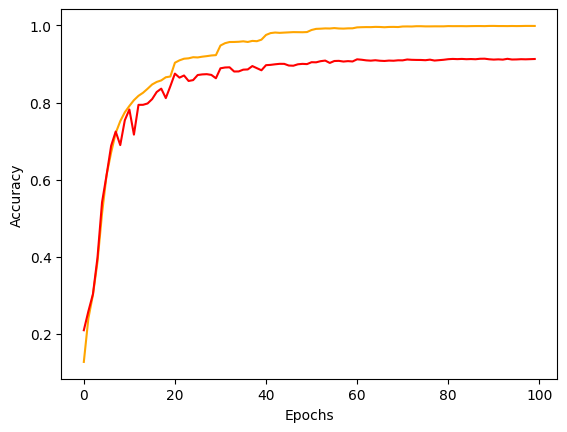

In [113]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

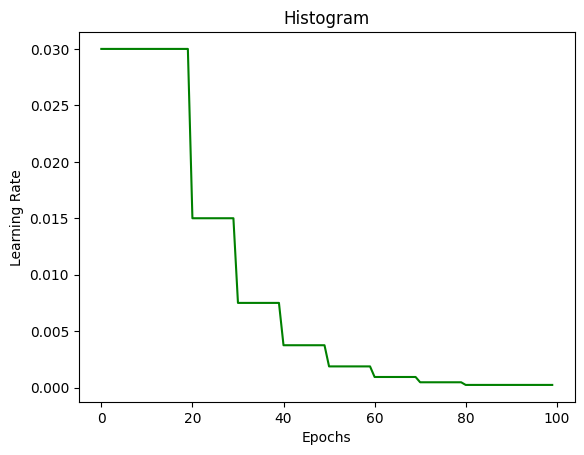

In [114]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [115]:
accu_epochs_train[99]

0.9984399676322937

In [116]:
accu_epochs_test[99]

0.9127999544143677

The accuracy of 91.2% is nearly identical to that of the All Convolutional Net from the last project. Let us try our reduced version next. 

In [117]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8,1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.Resize([32,32])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 200, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 200, shuffle = False)

# googlenet initialization
Inception_red_cuda = Inception_red(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_red_cuda(x);
Inception_red_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.Adam(Inception_red_cuda.parameters(), lr = 0.1, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40, 50, 60, 70, 80], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.01)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, Inception_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3617.660169363022


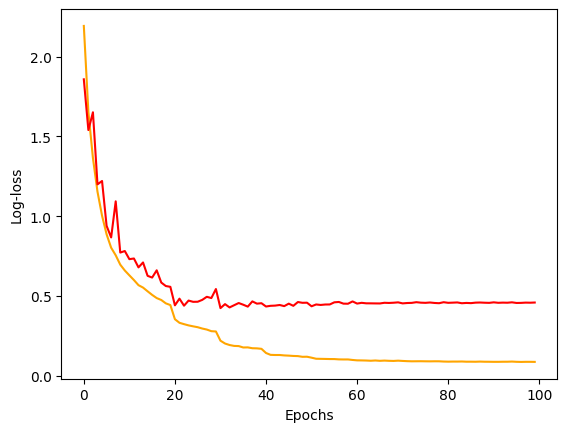

In [118]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

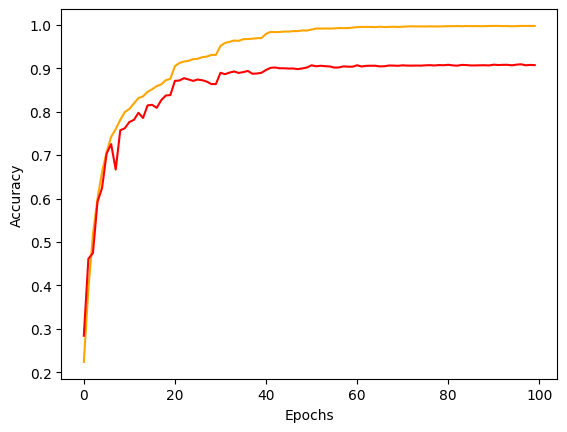

In [119]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [120]:
accu_epochs_train[99]

0.9972399473190308

In [121]:
accu_epochs_test[99]

0.9070999622344971

The performance noticeably degraded. We would probably have had to play with this architecture a bit more to achieve better performance (remember that we got 94.2% with the VGGNet-like model 3x64, 3x128, 3x256 with batch normalization and image augmentation). 

This is a bit of an issue with Inception architecture in general; it is a complex design that is not straightforward to systematically change. Comparatively speaking, in the next small project, we will take a look at the ResNet architecture from 2015, a quite simple yet revolutionary convolutional neural network that changed the design of all convolutional networks going forward. 

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> SZEGEDY, Christian, et al. Going deeper with convolutions. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2015. p. 1-9.

<a id="2">[2]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="3">[3]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.

<a id="4">[4]</a> IOFFE, Sergey; SZEGEDY, Christian. Batch normalization: Accelerating deep network training by reducing internal covariate shift. In: *International conference on machine learning.* pmlr, 2015. p. 448-456.

<a id="5">[5]</a> SZEGEDY, Christian, et al. Rethinking the inception architecture for computer vision. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2016. p. 2818-2826.

<a id="6">[6]</a> KINGMA, Diederik P.; BA, Jimmy. Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980, 2014.

<a id="7">[7]</a> KESKAR, Nitish Shirish; SOCHER, Richard. Improving generalization performance by switching from adam to sgd. arXiv preprint arXiv:1712.07628, 2017.

<a id="8">[8]</a> ZHOU, Pan, et al. Towards theoretically understanding why sgd generalizes better than adam in deep learning. Advances in Neural Information Processing Systems, 2020, 33: 21285-21296.

<a id="9">[9]</a> ZOU, Difan, et al. Understanding the generalization of adam in learning neural networks with proper regularization. arXiv preprint arXiv:2108.11371, 2021.

<a id="10">[10]</a> PAN, Yan; LI, Yuanzhi. Toward understanding why adam converges faster than sgd for transformers. arXiv preprint arXiv:2306.00204, 2023.

<a id="11">[11]</a> SZEGEDY, Christian, et al. Inception-v4, inception-resnet and the impact of residual connections on learning. In: *Proceedings of the AAAI conference on artificial intelligence.* 2017.
